# 251. Flatten 2D Vector
https://leetcode.com/problems/flatten-2d-vector/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| Flatten upfront | O(n) init | O(n) | Copy all elements to a 1D list |
| **Two Pointers (lazy)** | **O(1) amortized** | **O(1)** | **Track outer and inner indices** |

## Methodology

We maintain two pointers: `outer` for the current inner vector and `inner` for the position within that vector. The `hasNext()` method advances `outer` past empty vectors. The `next()` method returns the current element and advances `inner`. This achieves O(1) amortized time per operation with O(1) extra space.

## Solutions

### C#

In [ ]:
// 251. Flatten 2D Vector
// Time: O(1) amortized | Space: O(1)
public class Vector2D {
    private int[][] vec;
    private int outer = 0, inner = 0;
    
    public Vector2D(int[][] vec) {
        this.vec = vec;
    }
    
    public int Next() {
        HasNext();
        return vec[outer][inner++];
    }
    
    public bool HasNext() {
        while (outer < vec.Length && inner >= vec[outer].Length) {
            outer++;
            inner = 0;
        }
        return outer < vec.Length;
    }
}

### Python

In [ ]:
# 251. Flatten 2D Vector
# Time: O(1) amortized | Space: O(1)
class Vector2D:
    def __init__(self, vec: list[list[int]]):
        self.vec = vec
        self.outer = 0
        self.inner = 0
    
    def next(self) -> int:
        self.hasNext()
        val = self.vec[self.outer][self.inner]
        self.inner += 1
        return val
    
    def hasNext(self) -> bool:
        while self.outer < len(self.vec) and self.inner >= len(self.vec[self.outer]):
            self.outer += 1
            self.inner = 0
        return self.outer < len(self.vec)

### Go

In [ ]:
// 251. Flatten 2D Vector
// Time: O(1) amortized | Space: O(1)
type Vector2D struct {
    vec        [][]int
    outer, inner int
}

func Constructor(vec [][]int) Vector2D {
    return Vector2D{vec: vec}
}

func (v *Vector2D) Next() int {
    v.HasNext()
    val := v.vec[v.outer][v.inner]
    v.inner++
    return val
}

func (v *Vector2D) HasNext() bool {
    for v.outer < len(v.vec) && v.inner >= len(v.vec[v.outer]) {
        v.outer++
        v.inner = 0
    }
    return v.outer < len(v.vec)
}

### Rust

In [ ]:
// 251. Flatten 2D Vector
// Time: O(1) amortized | Space: O(1)
struct Vector2D {
    vec: Vec<Vec<i32>>,
    outer: usize,
    inner: usize,
}

impl Vector2D {
    fn new(vec: Vec<Vec<i32>>) -> Self {
        Vector2D { vec, outer: 0, inner: 0 }
    }
    
    fn next(&mut self) -> i32 {
        self.has_next();
        let val = self.vec[self.outer][self.inner];
        self.inner += 1;
        val
    }
    
    fn has_next(&mut self) -> bool {
        while self.outer < self.vec.len() && self.inner >= self.vec[self.outer].len() {
            self.outer += 1;
            self.inner = 0;
        }
        self.outer < self.vec.len()
    }
}

## Example Scenarios

1. **Common Case** — Simple 2D vector with varying row lengths  
   **Input:** `vec = [[1,2],[3],[4]]`  
   `next()` returns 1, 2, 3, 4 in order. `hasNext()` advances the outer pointer past exhausted rows. After 4 calls to `next()`, `hasNext()` returns false.

2. **Slightly Complex** — Empty inner vectors interspersed  
   **Input:** `vec = [[],[1,2],[],[],[3],[]]`  
   `hasNext()` must skip over empty sub-arrays. First call skips row 0 (empty), positions at row 1. After reading 1, 2 from row 1, skips rows 2 and 3 (empty), reads 3 from row 4, then skips row 5. Total elements: $3$.

3. **Edge Case: Time Factor** — Single row with $n$ elements  
   **Input:** `vec = [[1, 2, 3, ..., 10000]]`  
   The outer pointer never advances. Each `next()` and `hasNext()` is $O(1)$ with no row-skipping overhead. $10^4$ sequential reads from one contiguous row.

4. **Edge Case: Space Factor** — All empty rows  
   **Input:** `vec = [[], [], [], ..., []]` ($10^4$ empty arrays)  
   `hasNext()` scans through all $10^4$ empty rows in the worst case, finding no elements. Returns `false`. The iterator stores two pointers but no buffered data. $O(1)$ extra space.

5. **Almost-Impossible but Plausible** — Each row has exactly one element  
   **Input:** `vec = [[2147483647], [-2147483648], [0], ..., [42]]` ($n$ rows)  
   Every `next()` triggers an outer-pointer advance. `hasNext()` always moves to the next row. This maximizes row transitions — $n$ transitions for $n$ elements. Values span the full 32-bit integer range $[-2^{31}, 2^{31}-1]$.


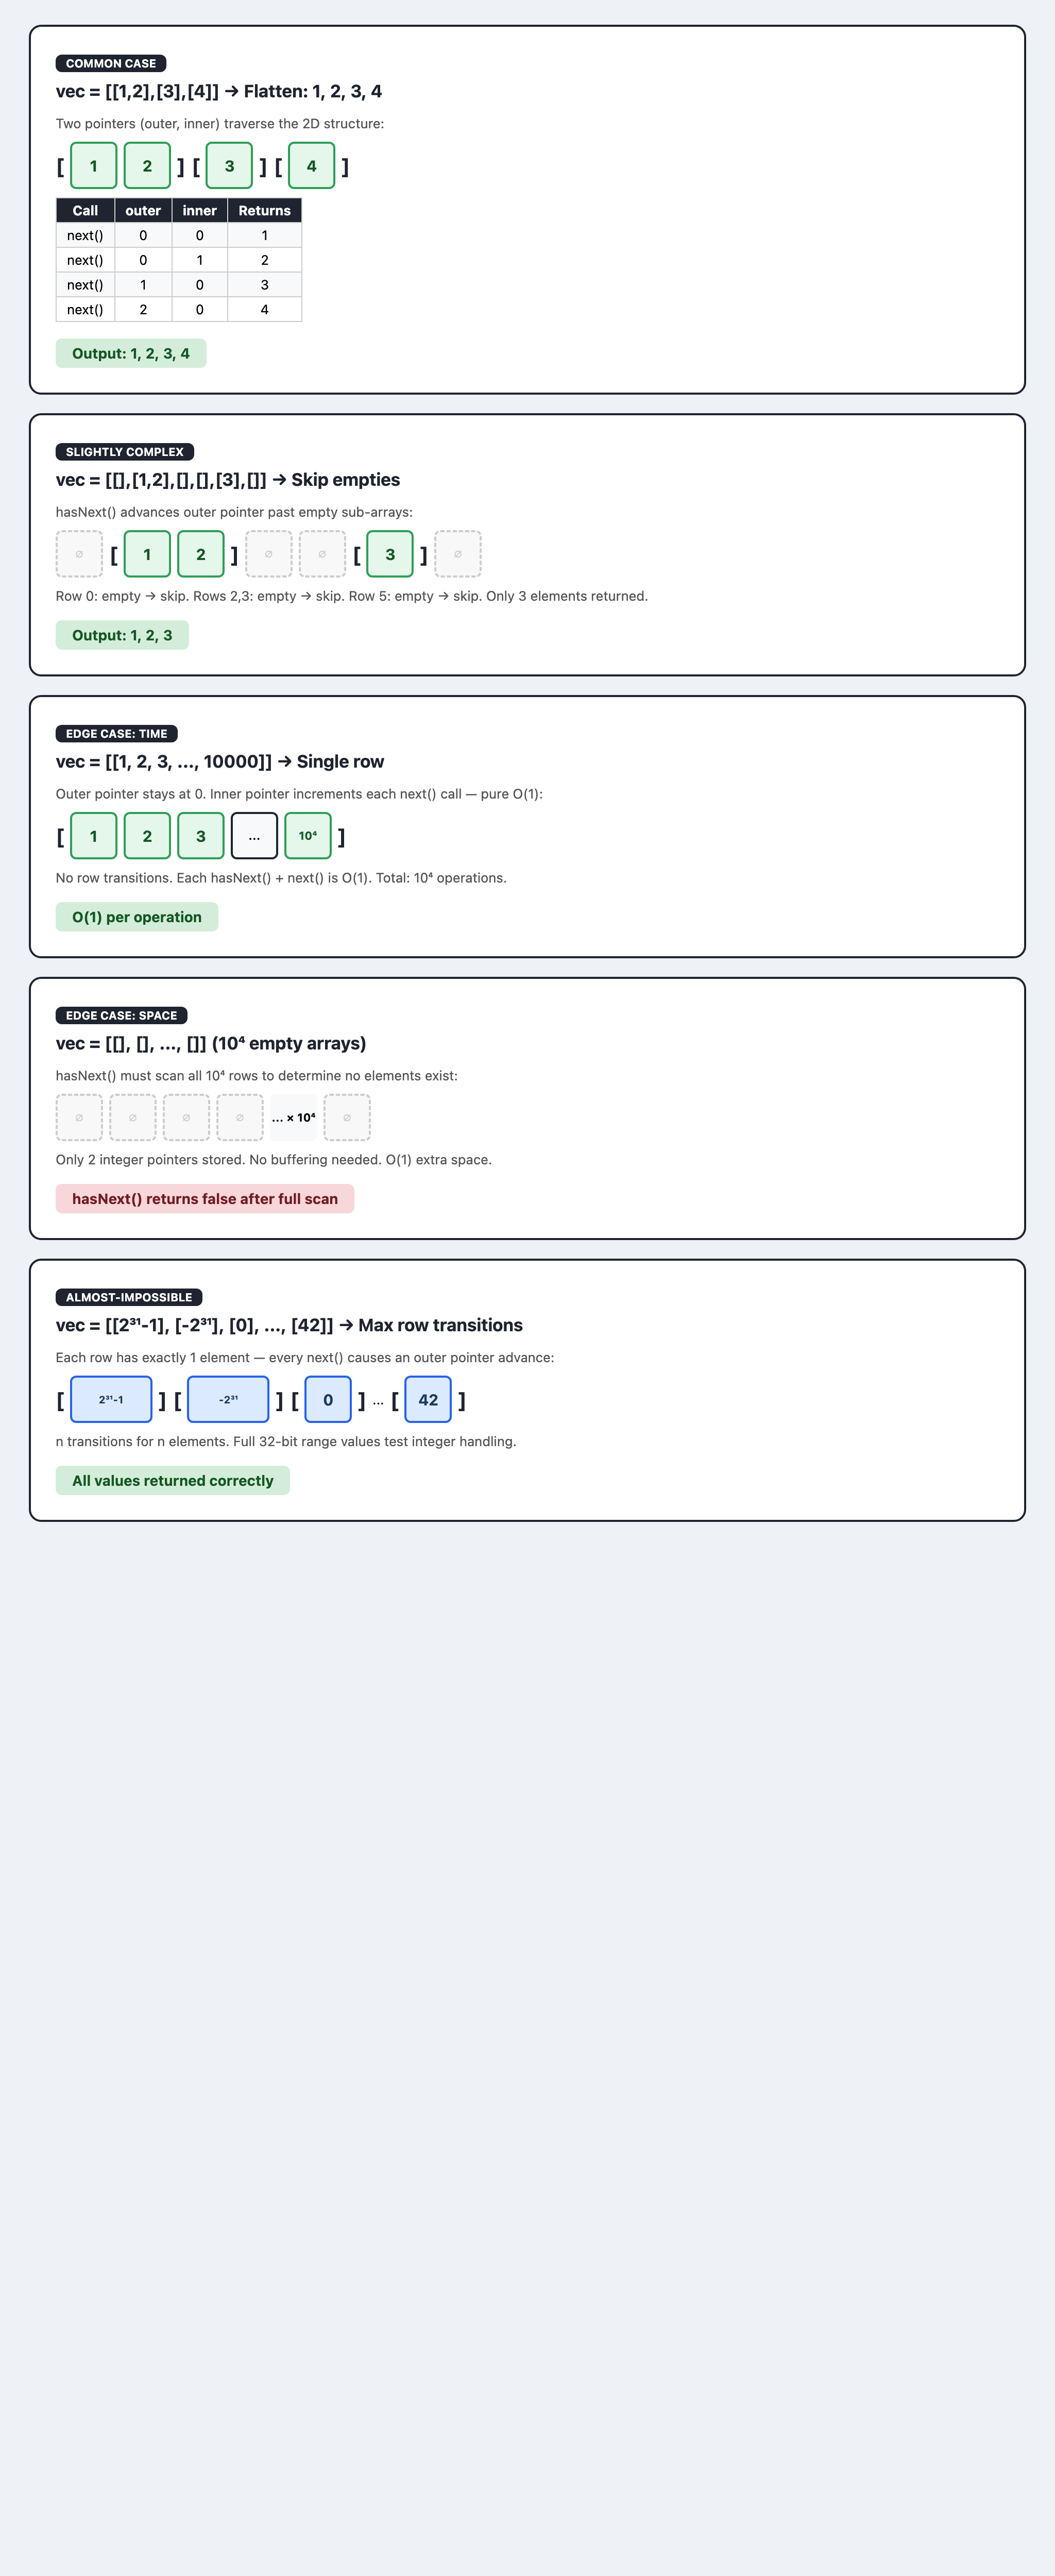